# QUESTION 1

## Imports

In [1]:
import numpy as np
import pandas as pd
import torch
from torchsummary import summary
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_regression, make_circles, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In this Exercise, you're going to train a neural network using the [Fashion-MNIST dataset](https://github.com/zalandoresearch/fashion-mnist). Fashion-MNIST is a set of 28 x 28 pixel greyscale images of clothes.

Some of you may have worked with this dataset before, it's a classic one. This dataset is ideal for your first PyTorch exercise. Below is a sample of some of the images in the dataset. We have 10 classes in the dataset: T-shirt/tops, Trousers, Pullovers, Dresses, Coats, Sandals, Shirts, Sneakers, Bags, and Ankle Boots.

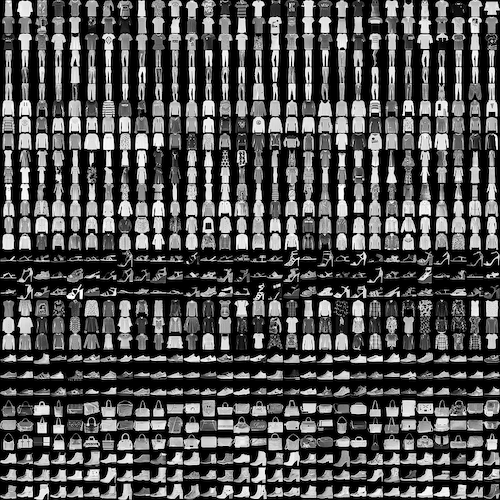

The goal of this question is to develop a network that can correctly predict a given image of "fashion" into one of the 10 classes. This is a multi-class classification task, our model should spit out 10 probabilities for a given image, one probability for each class. Ideally, the class our model predicts with maximum probability is the correct one.

The below cell will download and load in the Fashion-MNIST data for you. Note the following:

- Think of images as `ndarrays` of data, in the case of grayscale images like we have here, each pixel has a value between 0 and 1 indicating how "bright" that pixel is. So each image here is just a 28 x 28 `ndarray` with values ranging from 0 to 1 (when we get to colour images, it's exactly the same, except each pixel has 3 values, one for each of the colour channels Red, Blue, Green. If we had colour images here our array would be 28 x 28 x 3).

- `transform`: applies some transformations to the images. Here we are converting the data to tensors.

- `torch.utils.data.DataLoader`: these are _data loaders_. Think of them as generators. During training/testing, we can easily query them for a batch of data of size `BATCH_SIZE`.

The following cell might give you a warning, but no need to worry:

In [6]:
BATCH_SIZE = 64

# Define a transform to normalize the data, which usually helps with training
transform = transforms.Compose([transforms.ToTensor()])

# Download data
trainset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)
testset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=False, transform=transform)

# Create data loaders (these are just generators that will give us `batch_size` samples as a time)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=True)

# Class labels
class_labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

100%|██████████████████████████████████████| 26.4M/26.4M [00:02<00:00, 9.40MB/s]
100%|███████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 325kB/s]
100%|██████████████████████████████████████| 4.42M/4.42M [00:01<00:00, 4.35MB/s]
100%|██████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 4.29MB/s]


Let's plot a random image (run this cell as many times as you like to see different images):

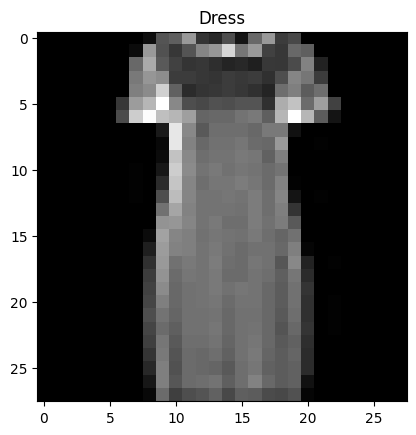

In [9]:
image, label = next(iter(trainloader))  # Get a random batch of 64 images
i = np.random.randint(0, 64)            # Choose one image at random
plt.imshow(image[i, 0], cmap='gray')    # Plot
plt.title(class_labels[label[i]]);

## 1.1

{accuracy: 3}

Notice in the plot above that our image is 28 x 28 pixels. How do we feed this into a neural network? Well we can flatten it out into a vector of 784 elements (28 x 28 = 784) and create 784 input nodes. We'll do this later on. For now, all I want you to do is create a new class for our PyTorch neural network model defining a classifier with the following architecture:

- hidden layer that goes from `input_size` -> 256 nodes

- ReLU activation function
- hidden layer that goes from 256 nodes -> 128 nodes
- ReLU activation function
- hidden layer that goes from 128 nodes -> 64 nodes
- ReLU activation function
- output layer that goes from 64 nodes -> `output_size` nodes

Following is some starter code to fill in.

**Note:** When we create our model in a later exercise we will specify `input_size=784` and `output_size=10`. The `784` is the flattened 28 x 28 image and the output size of 10 is so that we have one node for each item of clothing (remember we have 10 classes), and each node will contain the probability of that item of clothing being the one in a particular input image.

In [17]:
class Classifier(nn.Module):
    def __init__(self, input_size, output_size, hidden_layers=[128, 64]):
        super().__init__()
        
        # First hidden layer
        self.fc1 = nn.Linear(input_size, hidden_layers[0])
        
        # Second hidden layer
        self.fc2 = nn.Linear(hidden_layers[0], hidden_layers[1])
        
        # Output layer
        self.fc3 = nn.Linear(hidden_layers[1], output_size)
        
        # Activation function
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # Flatten the input if needed
        x = x.view(x.shape[0], -1)
        
        # Pass through first hidden layer with ReLU
        x = self.relu(self.fc1(x))
        
        # Pass through second hidden layer with ReLU
        x = self.relu(self.fc2(x))
        
        # Output layer (no activation - will use softmax later or in loss function)
        x = self.fc3(x)
        
        return x

In [22]:
# Create model instance
model = Classifier(input_size=784, output_size=10)

# Print model architecture
print(model)


test_input = torch.randn(1, 784)
output = model(test_input)
print(f"Output shape: {output.shape}") 

Classifier(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)
Output shape: torch.Size([1, 10])


## 1.2

{accuracy: 2}

If your model has `input_size=784` and `output_size=10`, how many parameters does your model have? Write your manual calculations, and verify your result using `torchsummary.summary()`.

In [24]:
# YOUR SOLUTION HERE
def trainer(model, criterion, optimizer, dataloader, epochs=5, verbose=True):
    """Simple training wrapper for PyTorch network."""
    
    train_losses = []
    
    for epoch in range(epochs):
        running_loss = 0.0
        
        for X, y in dataloader:
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass - reshape X from (batch, 1, 28, 28) to (batch, 784)
            y_hat = model(X.reshape(X.shape[0], -1))
            
            # Calculating loss
            loss = criterion(y_hat, y)
            
            # Backward pass
            loss.backward()
            
            # Updating weights
            optimizer.step()
            
            # Accumulating loss
            running_loss += loss.item()
        
        # Calculate average loss for this epoch
        epoch_loss = running_loss / len(dataloader)
        train_losses.append(epoch_loss)
        
        if verbose:
            print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}')
    
    return train_losses

## 1.3

{accuracy: 3}

We haven't trained yet, but let's test out your network. The below function will help you plot your network's predictions for a particular image using `matplotlib`, run it:

In [30]:
def plot_prediction(image, label, predictions):
    """Plot network predictions with matplotlib."""

    fig, (ax1, ax2) = plt.subplots(figsize=(8, 4), ncols=2)  # Plot
    ax1.imshow(image[0], cmap='gray')
    ax1.axis('off')
    ax1.set_title(class_labels[label])
    ax2.barh(np.arange(10), predictions.data.numpy().squeeze())
    ax2.set_title("Predictions")
    ax2.set_yticks(np.arange(10))
    ax2.set_yticklabels(class_labels)
    ax2.set_xlim(0, 1)
    plt.tight_layout();

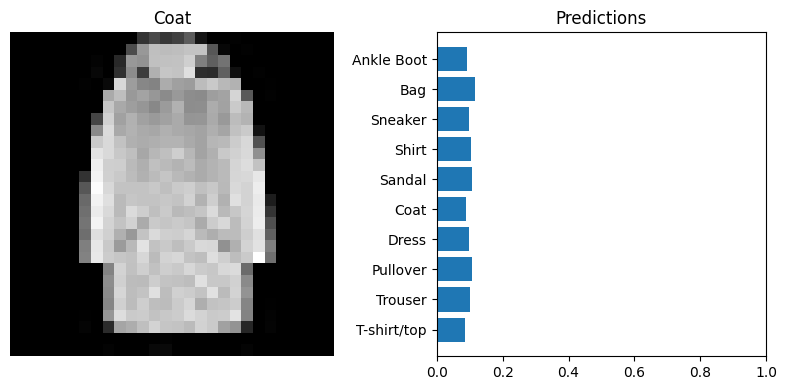

In [45]:
# ## Uncomment and run the following
model = Classifier(input_size=784, output_size=10)

# # Test on training images (run as many times as you like!)
image, label = next(iter(trainloader))        # Get a random batch of 64 images
predictions = model(image[0].reshape(1, -1))  # Get first image, flatten to shape (1, 784) and predict it
predictions = nn.Softmax(dim=1)(predictions)  # Coerce predictions to probabilities using Softmax()
plot_prediction(image[0], label[0], predictions)

Those predictions look probably pretty bad, because the model is not trained yet.

Below is a training function similar to what we saw in lectures. The only difference is that when I'm creating `y_hat` (model predictions), I'm reshaping my `X` data from `(batch_size, 1, 28, 28)` to `(batch_size, 784)`, so that we can feed it into our network. `X.shape[0]` is the batch size, and the `-1` just says _flatten remaining dimensions into a single dimension_.

In [48]:
def trainer(model, criterion, optimizer, dataloader, epochs=5, verbose=True):
    """Simple training wrapper for PyTorch network."""

    for epoch in range(epochs):
        losses = 0
        for X, y in dataloader:
            optimizer.zero_grad()       # Clear gradients w.r.t. parameters
            y_hat = model(X.reshape(X.shape[0], -1))  # Reshape data to (batch_size, 784) and forward pass to get output
            loss = criterion(y_hat, y)  # Calculate loss
            loss.backward()             # Getting gradients w.r.t. parameters
            optimizer.step()            # Update parameters
            losses += loss.item()       # Add loss for this batch to running total

        if verbose:
            print(f"epoch: {epoch + 1}, loss: {losses / len(dataloader):.4f}")

Now define an appropriate `criterion` and `optimizer` to train your model with.

- We are doing multi-class classification here, what loss function do we use for this case?

- Use any optimizer you like, but I recommend Adam

I already created the dataloader `trainloader` for you at the start of this exercise. Pass all these things to `trainer()` to train your model. Remember that it may take a few minutes to complete.

In [57]:
# YOUR SOLUTION HERE
def trainer(model, criterion, optimizer, dataloader, epochs=5, verbose=True):
    """Simple training wrapper for PyTorch network."""
    
    train_losses = []
    
    for epoch in range(epochs):
        running_loss = 0.0
        
        for X, y in dataloader:
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass - reshape X from (batch, 1, 28, 28) to (batch, 784)
            y_hat = model(X.reshape(X.shape[0], -1))
            
            # Calculate loss
            loss = criterion(y_hat, y)
            
            # Backward pass
            loss.backward()
            
            # Update weights
            optimizer.step()
            
            # Accumulate loss
            running_loss += loss.item()
        
        # Calculate average loss for this epoch
        epoch_loss = running_loss / len(dataloader)
        train_losses.append(epoch_loss)
        
        if verbose:
            print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}')
    
    return train_losses

## 1.4

{reasoning: 1}
Test out your newly trained network on the training data:

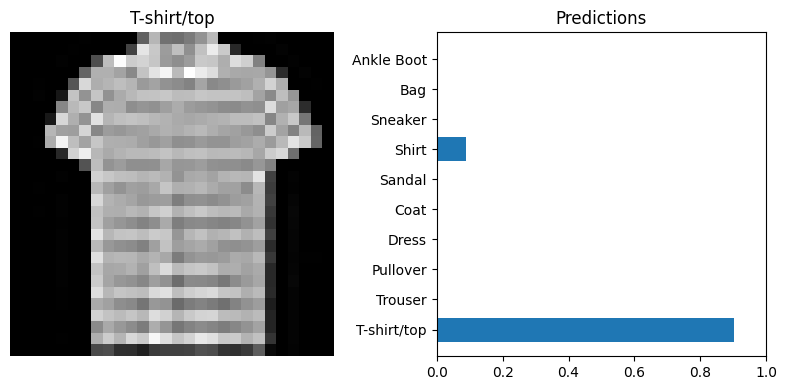

In [63]:
# ## Uncomment andrunthe following
# # Test model on training images (run as many times as you like!)
image, label = next(iter(trainloader))        # Get a random batch of 64 images

predictions = model(image[0].view(1, -1))     # Get first image, flatten to shape (1, 784) and predict it
predictions = nn.Softmax(dim=1)(predictions)  # Coerce predictions to probabilities using Softmax()
plot_prediction(image[0], label[0], predictions)

And test it out on the test data:

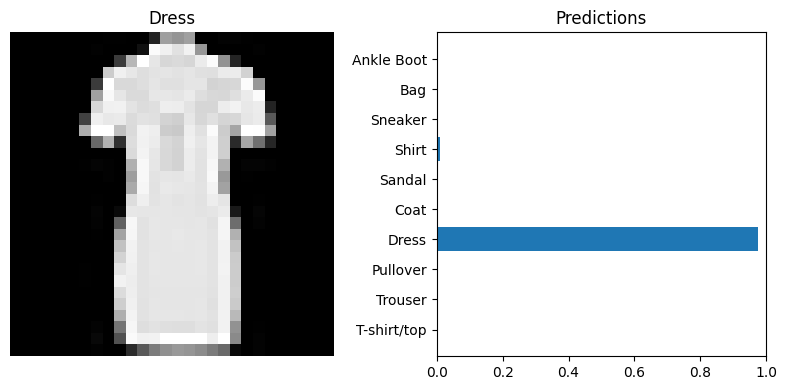

In [65]:
# ## Uncomment andrunthe following
# # Test model on testing images (run as many times as you like!)
image, label = next(iter(testloader))        # Get a random batch of 64 images
predictions = model(image[0].view(1, -1))     # Get first image, flatten to shape (1, 784) and predict it
predictions = nn.Softmax(dim=1)(predictions)  # Coerce predictions to probabilities using Softmax()
plot_prediction(image[0], label[0], predictions)

Hopefully your predictions look good. You just created your first neural network classifier!

**Now comes the question for you:** In this exercise we used a `BATCH_SIZE = 64`. Describe how choosing a small vs. large batch size affects the convergence of the optimization algorithm, as well as hardware requirements.

> YOUR ANSWER HERE

# QUESTION 2

### Question:

Consider a dataset represented as the following matrix, where each row corresponds to a sample and each column corresponds to a feature:

$$
\
X = \begin{bmatrix}
1 & 2 \\
2 & 3 \\
3 & 4 \\
4 & 5
\end{bmatrix}
$$


You are asked to apply three different kernels on this dataset: linear kernel, polynomial kernel (degree 2), and radial basis function (RBF) kernel. Answer the following:

1. Compute the kernel matrix for the **linear kernel** using $$\( K(x_i, x_j) = x_i^T x_j) \$$

2. Compute the kernel matrix for the **polynomial kernel (degree 2)** using $$\( K(x_i, x_j) = (x_i^T x_j + 1)^2) \$$

3. Describe the behavior of the **RBF kernel** in terms of feature space transformation. You don't need to compute it explicitly but explain how it handles data.


> YOUR SOLUTION HERE
1.

K[0,0] = [1,2]·[1,2] = 1×1 + 2×2 = 1 + 4 = 5
K[0,1] = [1,2]·[2,3] = 1×2 + 2×3 = 2 + 6 = 8
K[0,2] = [1,2]·[3,4] = 1×3 + 2×4 = 3 + 8 = 11
K[0,3] = [1,2]·[4,5] = 1×4 + 2×5 = 4 + 10 = 14

K[1,0] = [2,3]·[1,2] = 2×1 + 3×2 = 2 + 6 = 8
K[1,1] = [2,3]·[2,3] = 2×2 + 3×3 = 4 + 9 = 13
K[1,2] = [2,3]·[3,4] = 2×3 + 3×4 = 6 + 12 = 18
K[1,3] = [2,3]·[4,5] = 2×4 + 3×5 = 8 + 15 = 23

K[2,0] = [3,4]·[1,2] = 3×1 + 4×2 = 3 + 8 = 11
K[2,1] = [3,4]·[2,3] = 3×2 + 4×3 = 6 + 12 = 18
K[2,2] = [3,4]·[3,4] = 3×3 + 4×4 = 9 + 16 = 25
K[2,3] = [3,4]·[4,5] = 3×4 + 4×5 = 12 + 20 = 32

K[3,0] = [4,5]·[1,2] = 4×1 + 5×2 = 4 + 10 = 14
K[3,1] = [4,5]·[2,3] = 4×2 + 5×3 = 8 + 15 = 23
K[3,2] = [4,5]·[3,4] = 4×3 + 5×4 = 12 + 20 = 32
K[3,3] = [4,5]·[4,5] = 4×4 + 5×5 = 16 + 25 = 41
K_linear = [[5,  8,  11, 14],
            [8,  13, 18, 23],
            [11, 18, 25, 32],
            [14, 23, 32, 41]]

2.
K[0,0] = (5 + 1)² = 6² = 36   
K[0,1] = (8 + 1)² = 9² = 81
K[0,2] = (11 + 1)² = 12² = 144
K[0,3] = (14 + 1)² = 15² = 225

K[1,0] = (8 + 1)² = 9² = 81
K[1,1] = (13 + 1)² = 14² = 196
K[1,2] = (18 + 1)² = 19² = 361
K[1,3] = (23 + 1)² = 24² = 576

K[2,0] = (11 + 1)² = 12² = 144
K[2,1] = (18 + 1)² = 19² = 361
K[2,2] = (25 + 1)² = 26² = 676
K[2,3] = (32 + 1)² = 33² = 1089

K[3,0] = (14 + 1)² = 15² = 225
K[3,1] = (23 + 1)² = 24² = 576
K[3,2] = (32 + 1)² = 33² = 1089
K[3,3] = (41 + 1)² = 42² = 1764

K_poly = [[36,   81,   144,  225],
          [81,   196,  361,  576],
          [144,  361,  676,  1089],
          [225,  576,  1089, 1764]]

  3.  Infinite-Dimensional Feature Space:
The RBF kernel implicitly maps data to an infinite-dimensional feature space without explicitly computing the transformation. This is achieved through the kernel trick, where we only compute similarities between points rather than their explicit feature representations.

Non-linear Decision Boundaries:
  By mapping to infinite dimensions, RBF can handle highly non-linear patterns:

1. Can separate data that is not linearly separable in the original space
2. Creates smooth, curved decision boundaries
3. Particularly effective for complex classification problems





# QUESTION 3

### Question:

Consider a feedforward neural network with the following characteristics:
- The input feature vector is \( x = [2, -1, 3, 0] \) with 4 features.
- The network has one hidden layer with 3 neurons.
- The activation function for the hidden layer is the ReLU function.
- The output layer has 1 neuron with a sigmoid activation function, representing the probability of the positive class.
- The weights and biases are initialized as follows:
 - For the hidden layer:  
   $$  W^{(1)} = \begin{bmatrix} 0.2 & -0.5 & 0.1 & 0.4 \\ -0.3 & 0.8 & 0.5 & -0.2 \\ 0.7 & -0.4 & 0.2 & 0.1 \end{bmatrix}, \quad b^{(1)} = \begin{bmatrix} 0.1 \\ 0.2 \\ 0.3 \end{bmatrix}  $$
  - For the output layer:  
   $$  W^{(2)} = \begin{bmatrix} 0.5 & -0.6 & 0.3 \end{bmatrix}, \quad b^{(2)} = 0.2 $$


Answer the following questions:

1. **Forward Pass:**
   a. Compute the activations for the hidden layer and the final output of the network. Show all intermediate steps.
   
2. **Backward Pass (Gradient Calculation):**
   a. Assume the true label \( y = 1 \), and the binary cross-entropy loss function is:  
      $\[
      L = -(y \log(f) + (1 - y) \log(1 - f))
      \]$
      Compute the gradient of the loss function \( L \) with respect to the weights of the output layer. Show all steps.
   
3. **Weight Update:**
   a. Using a learning rate of $ \alpha = 0.01 $, write down the gradient descent update rule for the output layer weights. Compute the updated weights after one iteration.

4. **Activation Function Impact:**
   a. If we were to replace the ReLU activation in the hidden layer with a sigmoid activation, how would this change the forward pass? Provide the new expressions but no need to compute the output.

> YOUR SOLUTION HERE
1.
  z^(1) = W^(1) · x + b^(1)
  z₁^(1) = 0.2(2) + (-0.5)(-1) + 0.1(3) + 0.4(0) + 0.1
       = 0.4 + 0.5 + 0.3 + 0 + 0.1
       = 1.3

   z₂^(1) = -0.3(2) + 0.8(-1) + 0.5(3) + (-0.2)(0) + 0.2
       = -0.6 + (-0.8) + 1.5 + 0 + 0.2
       = 0.3

   z₃^(1) = 0.7(2) + (-0.4)(-1) + 0.2(3) + 0.1(0) + 0.3
       = 1.4 + 0.4 + 0.6 + 0 + 0.3
       = 2.7
       
       z^(1) = [1.3, 0.3, 2.7]

  ReLU(z) = max(0, z)

  a₁^(1) = max(0, 1.3) = 1.3
  a₂^(1) = max(0, 0.3) = 0.3
  a₃^(1) = max(0, 2.7) = 2.7
 a^(1) = [1.3, 0.3, 2.7]

 z^(2) = W^(2) · a^(1) + b^(2)

W^(2) = [0.5, -0.6, 0.3]
b^(2) = 0.2
a^(1) = [1.3, 0.3, 2.7]

z^(2) = 0.5(1.3) + (-0.6)(0.3) + 0.3(2.7) + 0.2
      = 0.65 + (-0.18) + 0.81 + 0.2
      = 1.48

σ(z) = 1 / (1 + e^(-z))

ŷ = σ(1.48) = 1 / (1 + e^(-1.48))
             = 1 / (1 + 0.2276)
             = 1 / 1.2276
             = 0.8146



2.  Step 1: Compute gradient of loss with respect to z^(2)

     ∂L/∂W^(2) = (∂L/∂z^(2)) · a^(1)

∂L/∂W₁^(2) = -0.1854 × 1.3 = -0.2410
∂L/∂W₂^(2) = -0.1854 × 0.3 = -0.0556
∂L/∂W₃^(2) = -0.1854 × 2.7 = -0.5006

Step 3: Compute gradient for output bias b^(2)

  ∂L/∂b^(2) = ∂L/∂z^(2) = -0.1854

3. updated layer:
W₁^(2)_new = 0.5 - 0.01(-0.2410) = 0.5 + 0.00241 = 0.5024
W₂^(2)_new = -0.6 - 0.01(-0.0556) = -0.6 + 0.000556 = -0.5994
W₃^(2)_new = 0.3 - 0.01(-0.5006) = 0.3 + 0.005006 = 0.3050

updated output bias :
b^(2)_new = 0.2 - 0.01(-0.1854) = 0.2 + 0.001854 = 0.2019


4. Hidden layer activation becomes
   a^(1) = σ(z^(1)) = σ(W^(1) · x + b^(1))

Instead of:
a^(1) = ReLU(z^(1)) = max(0, W^(1) · x + b^(1))

With ReLU:
a^(1) = [1.3, 0.3, 2.7]

With Sigmoid:
a₁^(1) = σ(1.3) = 1/(1+e^(-1.3)) = 0.7858
a₂^(1) = σ(0.3) = 1/(1+e^(-0.3)) = 0.5744
a₃^(1) = σ(2.7) = 1/(1+e^(-2.7)) = 0.9370

a^(1) = [0.7858, 0.5744, 0.9370]

Impact on output:

Values are compressed to (0, 1) range instead of [0, ∞)
Smaller activation values → different final output
Gradient flow changes (sigmoid has vanishing gradient problem)


Backward pass changes:
 
 ReLU gradient: 1 if z > 0, else 0
 Sigmoid gradient: σ(z)(1 - σ(z))
 Sigmoid gradients are always < 0.25, leading to slower learning


# QUESTION 4

Adam (adaptive moment estimation) is an optimization algorithm that we'll be using a lot for the rest of the course. [Here](https://arxiv.org/abs/1412.6980)'s the original paper that proposed the algorithm. It is essentially a fancier version of SGD. Without getting too technical, Adam really adds two additional features to SGD:

1. Momentum: which uses past gradients to help improve convergence speed, reduce noise in the path to the minimum, and avoid local minima.

2. Per-parameter learning rate: a learning rate is maintained and adapted for each parameter as iterations of optimization proceed.

Recommended: [read this article](https://ruder.io/optimizing-gradient-descent/index.html) to learn more, but Adam boils down to the following weight updating procedure:

$$\mathbf{w}_{t+1} = \mathbf{w}_{t} - \frac{\alpha}{\sqrt{\hat{v}_{t}} + \epsilon} \hat{m}_{t}$$

The various components required for that equation:

$$\begin{align}
\hat{m}_{t} &= \frac{m_{t}}{1 - \beta_{1}^{t}}\\
\hat{v}_{t} &= \frac{v_{t}}{1 - \beta_{2}^{t}}
\end{align}$$

$$\begin{align}
m_{t} &= \beta_{1} m_{t-1} + (1 - \beta_{1}) g_{t}\\
v_{t} &= \beta_{2} v_{t-1} + (1 - \beta_{2}) g_{t}^{2}
\end{align}$$

Where:

- $t$ is the iteration of optimization, it increments up by one each time you update $\mathbf{w}$. Note that in the equation for $\hat{m}_{t}$ and $\hat{v}_{t}$, $\beta_{1}$ and $\beta_{2}$ are raised to the power of $t$.

- $g_{t}$ is the gradient of the loss function w.r.t to the parameters $w$.
- $m_{t}$ is known as the first moment (the mean) of the gradients. In the first iteration, initialize $m_{-1}$ to 0 to get the solution started.
- $v_{t}$ is known as the second moment (the uncentered variance) of the gradients. In the first iteration, initialize $v_{-1}$ to 0 to get the solution started.
- $\alpha$ is the learning rate. 0.1 is a good start.
- $\epsilon$ is just a term to prevent division by zero. Default: $10^{-8}$.
- $\beta_{1}$ is a hyperparameter that controls the influence of past gradients on subsequent updates. Default: $0.9$.
- $\beta_{2}$ is a hyperparameter that controls the influence of past gradients on subsequent updates. Default: $0.999$.

Here's a function with both local and global minima. We know in advance that the global minimum occurs at $w_{opt}=4$. I want you to find this value using Adam optimization and starting at $w \neq w_{opt}$. I've provided you the function (`f()`), the MSE loss w.r.t this function (`loss()`), and the gradient of the loss (`loss_grad()`). Run the cell below:

#### Imports

In [96]:
import numpy as np
import matplotlib.pyplot as plt

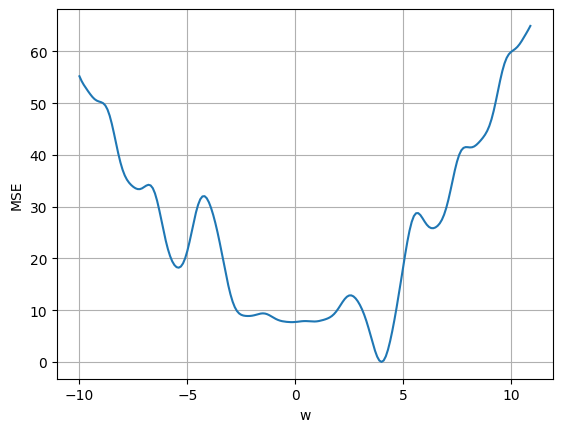

In [98]:
def f(w, X):
    """Squiggly function"""
    return w * np.cos(w * X)

def loss(w, X, y):
    """MSE loss."""
    return np.mean((f(w, X) - y) ** 2)

def loss_grad(w, X, y):
    """Gradient of MSE."""
    t = np.cos(w * X) - w * X * np.sin(w * X)
    return np.mean((f(w, X) - y) * t)

w_opt = 4
X = np.arange(-3, 3, 0.1)
y = f(w_opt, X)
l = [loss(w, X, y) for w in np.arange(-10, 11, 0.1)]

plt.plot(np.arange(-10, 11, 0.1), l)
plt.xlabel("w")
plt.ylabel("MSE")
plt.grid(True);

Your task here is to implement Adam from scratch. Then use it to find $w_{opt}$ for the above function. Some code has been provided below that you should run when you're ready. Note that:

-  A default of 100 epochs is specified. We have a *tiny* dataset here of 60 samples so this is nothing substantial. Feel free to add more epochs if you wish.

- You can start with the default values for the various Adam terms I give in the equations above.
- You *may* need to play around with the hyperparameter $\alpha$ to get to the minimum (I've given a default of 0.3 in the starter code below. I didn't need to change this value in my solution). You can leave $\beta_{1}$, $\beta_{2}$ as is - Often we don't tune those ones and I didn't in my solution, but you can tune them if you want.
- Adam uses batches just like SGD, so my solution has the ability to accept a `batch_size` argument. But you don't have to implement this functionality and I didn't include that argument in the starter code below. So feel free to just use all the data each iteration for simplicity like vanilla GD would do. If you're feeling adventurous, no one should stop you from throwing in a `batch_size` argument.

The pedagogical goal here is to get you to implement Adam and play around with it to see how it can **jump over** local minima.

_Points:_ 2

In [100]:
# Define the loss function with local minimum at w=2 and global minimum at w=4
def loss(X, y, w):
    """Loss function: (w-2)^2 * (w-4)^2"""
    return (w[0] - 2)**2 * (w[0] - 4)**2

def loss_grad(X, y, w):
    """Gradient of the loss function"""
    return np.array([2*(w[0]-2)*(w[0]-4)**2 + 2*(w[0]-2)**2*(w[0]-4)])

# Dummy X and y (not actually used in this toy problem)
X = np.array([[1]])
y = np.array([1])

In [102]:
def Adam(X, y, w0, loss, loss_grad, n_epochs=100, batch_size=1, alpha=0.3, beta1=0.9, beta2=0.999, eta=1e-8, verbose=False):
    """Adam optimization algorithm implementation."""
    
    # Initialize parameters
    w = w0.copy()
    m = np.zeros_like(w)  # First moment
    v = np.zeros_like(w)  # Second moment
    t = 0  # Time step
    
    for epoch in range(n_epochs):
        t += 1
        
        # Compute gradient
        g_t = loss_grad(X, y, w)
        
        # Update biased first moment estimate
        m = beta1 * m + (1 - beta1) * g_t
        
        # Update biased second raw moment estimate
        v = beta2 * v + (1 - beta2) * (g_t ** 2)
        
        # Compute bias-corrected first moment estimate
        m_hat = m / (1 - beta1 ** t)
        
        # Compute bias-corrected second raw moment estimate
        v_hat = v / (1 - beta2 ** t)
        
        # Update weights
        w = w - (alpha / (np.sqrt(v_hat) + eta)) * m_hat
        
        if verbose and (epoch % 10 == 0 or epoch == n_epochs - 1):
            current_loss = loss(X, y, w)
            print(f'Epoch {epoch}: Loss={current_loss:.6f}, w={w[0]:.4f}')
    
    return w

In [104]:
w0 = np.array([9])
w = Adam(X, y, w0, loss, loss_grad)
print(w)  # Should be close to 4

[3.60470293]


Running SGD...
SGD final w: nan

Running Adam...
Adam final w: 3.6047



/var/folders/34/jqpjg_x508j0x978h6stq2j80000gn/T/ipykernel_8264/2188811783.py:4: RuntimeWarning: overflow encountered in scalar multiply
  return (w[0] - 2)**2 * (w[0] - 4)**2
/var/folders/34/jqpjg_x508j0x978h6stq2j80000gn/T/ipykernel_8264/2188811783.py:8: RuntimeWarning: overflow encountered in scalar multiply
  return np.array([2*(w[0]-2)*(w[0]-4)**2 + 2*(w[0]-2)**2*(w[0]-4)])
/var/folders/34/jqpjg_x508j0x978h6stq2j80000gn/T/ipykernel_8264/1674274442.py:13: RuntimeWarning: invalid value encountered in subtract
  w = w - learning_rate * grad


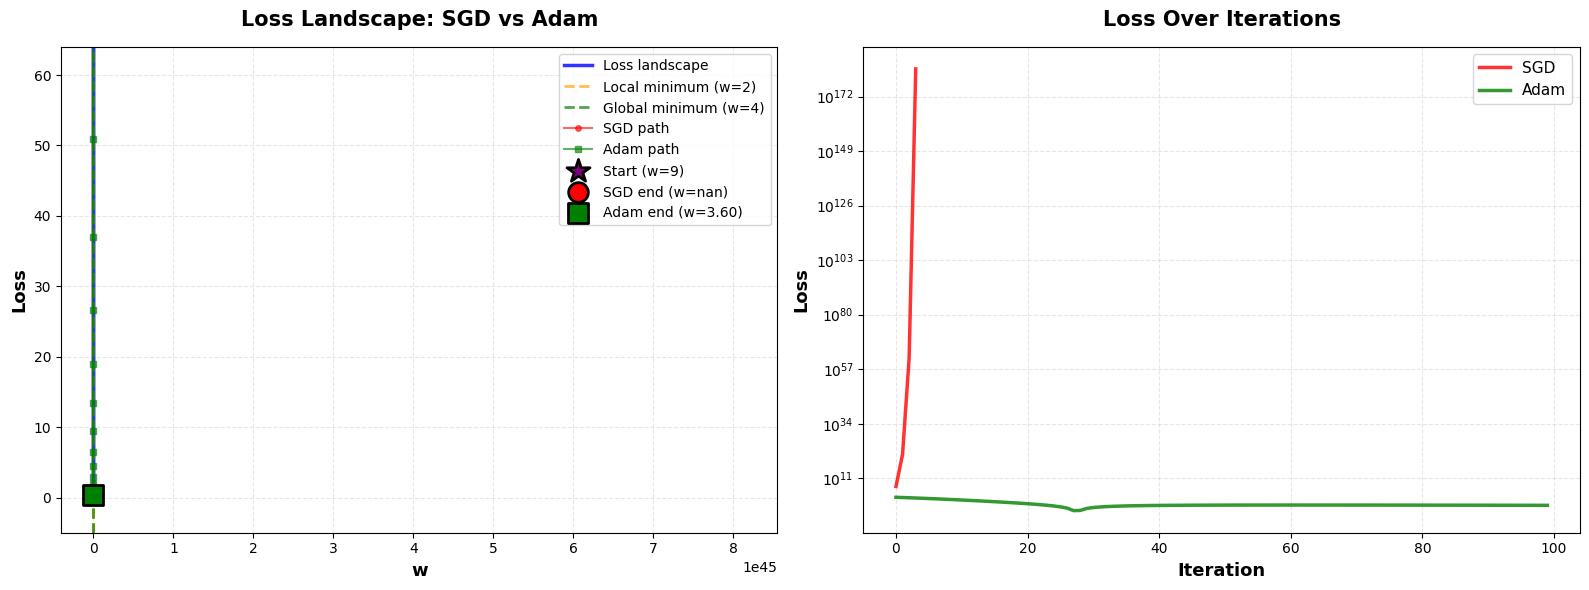

In [106]:
# BEGIN SOLUTION
# Compare SGD and Adam

# Define SGD for comparison
def SGD(X, y, w0, loss, loss_grad, n_epochs=100, learning_rate=0.1, verbose=False):
    """Simple SGD implementation for comparison"""
    w = w0.copy()
    loss_history = []
    w_history = [w0[0]]
    
    for epoch in range(n_epochs):
        grad = loss_grad(X, y, w)
        w = w - learning_rate * grad
        
        current_loss = loss(X, y, w)
        loss_history.append(current_loss)
        w_history.append(w[0])
        
        if verbose and (epoch % 10 == 0):
            print(f'Epoch {epoch}, Loss: {current_loss:.6f}, w: {w[0]:.4f}')
    
    return w, loss_history, w_history

# Modified Adam to track history
def Adam_with_history(X, y, w0, loss, loss_grad, n_epochs=100, alpha=0.3, beta1=0.9, beta2=0.999, eta=1e-8):
    """Adam with history tracking for plotting"""
    w = w0.copy()
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    t = 0
    
    loss_history = []
    w_history = [w0[0]]
    
    for epoch in range(n_epochs):
        t += 1
        g_t = loss_grad(X, y, w)
        
        m = beta1 * m + (1 - beta1) * g_t
        v = beta2 * v + (1 - beta2) * (g_t ** 2)
        
        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)
        
        w = w - (alpha / (np.sqrt(v_hat) + eta)) * m_hat
        
        current_loss = loss(X, y, w)
        loss_history.append(current_loss)
        w_history.append(w[0])
    
    return w, loss_history, w_history

# Run both optimizers
w0_test = np.array([9.0])

print("Running SGD...")
w_sgd, sgd_losses, sgd_w_history = SGD(X, y, w0_test, loss, loss_grad, n_epochs=100, learning_rate=0.1)
print(f"SGD final w: {w_sgd[0]:.4f}\n")

print("Running Adam...")
w_adam, adam_losses, adam_w_history = Adam_with_history(X, y, w0_test, loss, loss_grad, n_epochs=100, alpha=0.3)
print(f"Adam final w: {w_adam[0]:.4f}\n")

# Code to plot and compare SGD and Adam
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Loss Landscape with optimizer paths
ax1 = axes[0]
w_range = np.linspace(0, 10, 500)
loss_values = [(w - 2)**2 * (w - 4)**2 for w in w_range]

ax1.plot(w_range, loss_values, 'b-', label='Loss landscape', linewidth=2.5, alpha=0.8)
ax1.axvline(x=2, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Local minimum (w=2)')
ax1.axvline(x=4, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Global minimum (w=4)')

# Plot optimizer paths
ax1.plot(sgd_w_history, [loss(X, y, np.array([w])) for w in sgd_w_history], 
         'ro-', markersize=4, linewidth=1.5, alpha=0.6, label='SGD path')
ax1.plot(adam_w_history, [loss(X, y, np.array([w])) for w in adam_w_history], 
         'gs-', markersize=4, linewidth=1.5, alpha=0.6, label='Adam path')

# Mark start and end points
ax1.scatter([9], [loss(X, y, np.array([9]))], c='purple', s=300, marker='*', 
            label='Start (w=9)', zorder=5, edgecolors='black', linewidths=2)
ax1.scatter([w_sgd[0]], [loss(X, y, w_sgd)], c='red', s=200, marker='o', 
            label=f'SGD end (w={w_sgd[0]:.2f})', zorder=5, edgecolors='black', linewidths=2)
ax1.scatter([w_adam[0]], [loss(X, y, w_adam)], c='green', s=200, marker='s', 
            label=f'Adam end (w={w_adam[0]:.2f})', zorder=5, edgecolors='black', linewidths=2)

ax1.set_xlabel('w', fontsize=13, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax1.set_title('Loss Landscape: SGD vs Adam', fontsize=15, fontweight='bold', pad=15)
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_ylim([-5, max(loss_values[:100])])

# Plot 2: Loss over iterations
ax2 = axes[1]
ax2.plot(sgd_losses, 'r-', linewidth=2.5, alpha=0.8, label='SGD')
ax2.plot(adam_losses, 'g-', linewidth=2.5, alpha=0.8, label='Adam')
ax2.set_xlabel('Iteration', fontsize=13, fontweight='bold')
ax2.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax2.set_title('Loss Over Iterations', fontsize=15, fontweight='bold', pad=15)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_yscale('log')  # Log scale to see both better

plt.tight_layout()
plt.show()


# END SOLUTION